In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import time

from dotenv import load_dotenv
from google import genai
from groq import Groq

load_dotenv()

True

LOAD DATA

In [2]:
df = pd.read_csv("data/patient_data.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (100, 18)


,patient_id,patient_name,age,gender,diagnosis,current_medication,lab_test,lab_value,lab_unit,last_visit_date,next_scheduled_visit,days_since_last_visit,missed_last_appointment,vitals_bp_systolic,vitals_bp_diastolic,vitals_heart_rate,vitals_spo2,notes
0,P0001,Aarav Sharma,68,Male,Type 2 Diabetes,Metformin 500mg,HbA1c,9.9,%,2024-04-24,2024-06-08,251,No,174,70,95,96,Patient reports good medication adherence.
1,P0002,Priya Patel,29,Male,Heart Failure,Furosemide 40mg,BNP,317.6,pg/mL,2024-01-14,2024-02-28,352,No,174,91,72,97,Patient reports no new symptoms.
2,P0003,Rohan Mehta,45,Male,"Type 2 Diabetes, CKD","Insulin Glargine 10U, Losartan 50mg",HbA1c,11.4,%,2024-08-04,2024-10-03,149,No,132,86,64,91,Medication dose adjusted this visit.
3,P0004,Anjali Singh,34,Female,"COPD, Heart Failure","Tiotropium 18mcg, Furosemide 40mg",FEV1%,33.8,%,2024-01-23,2024-04-22,343,No,153,70,93,94,Patient reports no new symptoms.
4,P0005,Vikram Nair,51,Male,"Hypertension, Heart Failure","Amlodipine 5mg, Furosemide 40mg",BP Systolic,124.9,mmHg,2024-04-26,2024-06-25,249,No,134,71,82,94,Patient education provided on diet and lifestyle.


Task 1: EDA OF FEATURES

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   patient_id               100 non-null    str    
 1   patient_name             100 non-null    str    
 2   age                      100 non-null    int64  
 3   gender                   100 non-null    str    
 4   diagnosis                100 non-null    str    
 5   current_medication       100 non-null    str    
 6   lab_test                 100 non-null    str    
 7   lab_value                100 non-null    float64
 8   lab_unit                 100 non-null    str    
 9   last_visit_date          100 non-null    str    
 10  next_scheduled_visit     100 non-null    str    
 11  days_since_last_visit    100 non-null    int64  
 12  missed_last_appointment  100 non-null    str    
 13  vitals_bp_systolic       100 non-null    int64  
 14  vitals_bp_diastolic      100 non-null 

In [4]:
df.isnull().sum()

patient_id                 0
patient_name               0
age                        0
gender                     0
diagnosis                  0
current_medication         0
lab_test                   0
lab_value                  0
lab_unit                   0
last_visit_date            0
next_scheduled_visit       0
days_since_last_visit      0
missed_last_appointment    0
vitals_bp_systolic         0
vitals_bp_diastolic        0
vitals_heart_rate          0
vitals_spo2                0
notes                      0
dtype: int64

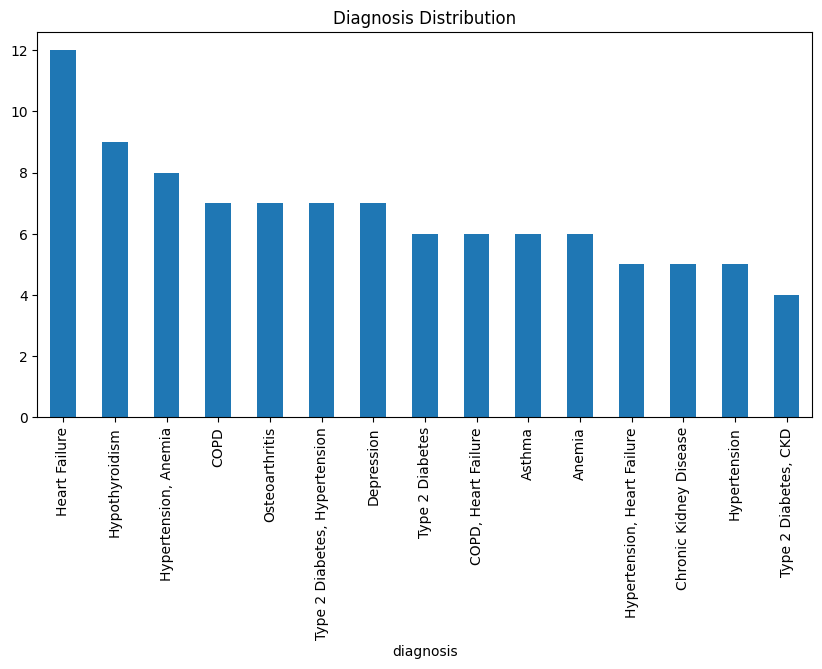

In [5]:
df["diagnosis"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Diagnosis Distribution")

plt.show()

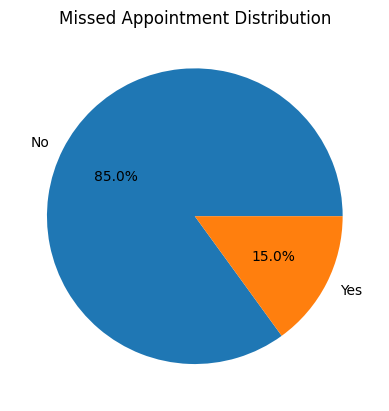

In [6]:
df["missed_last_appointment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Missed Appointment Distribution")

plt.show()

Task 2: Tool Definitions

In [7]:
def get_patient(df, patient_id):

    patient = df[df["patient_id"] == patient_id]

    if patient.empty:
        return None

    return patient.iloc[0].to_dict()


def get_high_risk_patients(df):

    return df[
        (df["days_since_last_visit"] > 180)
        |
        (df["missed_last_appointment"] == "Yes")
        |
        (df["vitals_bp_systolic"] > 160)
        |
        (df["vitals_spo2"] < 92)
    ]


def get_missed_appointments(df):

    return df[
        df["missed_last_appointment"] == "Yes"
    ]

Agent Prompt

In [8]:
PATIENT_ANALYSIS_PROMPT = """
You are a healthcare care-coordination agent.

Review the patient information.

Provide:

1. Risk Level
2. Clinical Concerns
3. Recommended Actions
4. Priority Score (1-10)

Patient Data:

{patient_data}
"""

Gemini Client

In [9]:
client = Groq(
    api_key=os.getenv("GROQ_API_KEY")
)

Task 3: Agent Functions

In [10]:
def analyze_patient(patient_data):

    prompt = PATIENT_ANALYSIS_PROMPT.format(
        patient_data=patient_data
    )

    for attempt in range(3):

        try:

            response = client.chat.completions.create(
                model="llama-3.3-70b-versatile",
                messages=[
                    {
                        "role": "system",
                        "content": "You are a healthcare care-coordination agent."
                    },
                    {
                        "role": "user",
                        "content": prompt
                    }
                ],
                temperature=0.2
            )

            return response.choices[0].message.content

        except Exception as e:

            print(f"Retry {attempt + 1}: {e}")

            time.sleep(5)

    return "Analysis unavailable"

In [11]:
def run_patient_review(patient):

    analysis = analyze_patient(patient)

    return {
        "patient_id": patient["patient_id"],
        "analysis": analysis
    }

In [12]:
def run_high_risk_agent(df):

    patients = get_high_risk_patients(df)

    results = []

    for _, patient in patients.head(5).iterrows():

        results.append(
            run_patient_review(
                patient.to_dict()
            )
        )

    return results

In [13]:
def run_missed_appointment_agent(df):

    patients = get_missed_appointments(df)

    results = []

    for _, patient in patients.head(5).iterrows():

        results.append(
            run_patient_review(
                patient.to_dict()
            )
        )

    return results

Task 4 – Single Patient Analysis

In [14]:
sample_patient_id = df.iloc[0]["patient_id"]

patient = get_patient(
    df,
    sample_patient_id
)

patient

{'patient_id': 'P0001',
 'patient_name': 'Aarav Sharma',
 'age': 68,
 'gender': 'Male',
 'diagnosis': 'Type 2 Diabetes',
 'current_medication': 'Metformin 500mg',
 'lab_test': 'HbA1c',
 'lab_value': 9.9,
 'lab_unit': '%',
 'last_visit_date': '2024-04-24',
 'next_scheduled_visit': '2024-06-08',
 'days_since_last_visit': 251,
 'missed_last_appointment': 'No',
 'vitals_bp_systolic': 174,
 'vitals_bp_diastolic': 70,
 'vitals_heart_rate': 95,
 'vitals_spo2': 96,
 'notes': 'Patient reports good medication adherence.'}

In [15]:
result = run_patient_review(patient)

print(result)

{'patient_id': 'P0001', 'analysis': "Based on the patient data, here's my assessment:\n\n1. **Risk Level**: High\nThe patient's HbA1c level is 9.9%, which is above the target range for patients with Type 2 Diabetes. This indicates poor blood sugar control, putting the patient at risk for complications such as cardiovascular disease, kidney damage, and nerve damage. Additionally, the patient's systolic blood pressure is elevated at 174 mmHg, which further increases the risk of cardiovascular complications.\n\n2. **Clinical Concerns**:\n\t* Poor blood sugar control (HbA1c 9.9%)\n\t* Elevated systolic blood pressure (174 mmHg)\n\t* Potential for cardiovascular complications\n\t* Risk of kidney damage and nerve damage due to uncontrolled diabetes\n\n3. **Recommended Actions**:\n\t* Adjust the patient's current medication regimen to improve blood sugar control. Consider adding another medication or increasing the dose of Metformin.\n\t* Refer the patient to a cardiologist to evaluate and ma

Task 5 – Missed Appointment Follow-Up

In [16]:
missed_results = run_missed_appointment_agent(df)

print(
    "Patients Reviewed:",
    len(missed_results)
)

Patients Reviewed: 5


In [17]:
for result in missed_results[:3]:

    print("="*80)

    print(result)

{'patient_id': 'P0018', 'analysis': "**Patient Review: Lakshmi Menon (P0018)**\n\n1. **Risk Level**: High\nThe patient's high BNP level (952.3 pg/mL) and elevated systolic blood pressure (160 mmHg) indicate a high risk of heart failure exacerbation. The patient's history of missing appointments also increases the risk of poor disease management.\n\n2. **Clinical Concerns**:\n   - Elevated BNP level, indicating potential heart failure exacerbation\n   - High systolic blood pressure, which can worsen heart failure\n   - Missed last appointment, suggesting potential gaps in care and disease management\n   - Potential non-adherence to medication and lifestyle recommendations\n\n3. **Recommended Actions**:\n   - Urgent follow-up appointment to reassess the patient's condition and adjust treatment as needed\n   - Medication adherence counseling to ensure the patient is taking Furosemide as prescribed\n   - Intensified patient education on diet, lifestyle, and importance of regular follow-ups

High-Risk Patient Analysis

In [18]:
high_risk_results = run_high_risk_agent(df)

print(
    "High Risk Patients Reviewed:",
    len(high_risk_results)
)

High Risk Patients Reviewed: 5


In [19]:
high_risk_results = run_high_risk_agent(df)

print(
    "High Risk Patients Reviewed:",
    len(high_risk_results)
)

High Risk Patients Reviewed: 5


Report Generation

In [20]:
report_df = pd.DataFrame(
    missed_results
)

report_df.head()


report_df.to_csv(
    "followup_report.csv",
    index=False
)

print(
    "Report Generated Successfully"
)

Report Generated Successfully


Summary

In [21]:
print("Total Patients:", len(df))

print(
    "High Risk Patients:",
    len(get_high_risk_patients(df))
)

print(
    "Missed Appointments:",
    len(get_missed_appointments(df))
)

Total Patients: 100
High Risk Patients: 82
Missed Appointments: 15
